# The Parameter System: A Deep Dive

Everything that reaches a `uvspec` input file goes through **one parameter
system**. This notebook walks the whole rabbit hole:

1. The four layers: config defaults → dotted config overrides → `params` literals → per-point `Var`
2. Pre-flight validation against *your* libRadtran install (typos, choices, ranges)
3. Exploring every uvspec option from Python: `describe()` and `search_options()`
4. Repeatable options, flag options, and the `Raw` escape hatch
5. Running a batch: `status` codes and what happens to NaNs
6. Post-processing: instrument channels and sensitivity kernels

Every simulation here is deliberately tiny (three points, 400–450 nm,
two-stream solver), so the whole notebook runs in seconds.

In [1]:
import logging

import numpy as np
import pandas as pd
import xarray as xr

import pyradtran
from pyradtran import Var, Raw, load_config
from pyradtran.exceptions import ValidationError

logging.getLogger('pyradtran').setLevel(logging.WARNING)
pyradtran.__version__

'0.2.0'

## Setup: a tiny scene

The input dataset answers *where and when*; the config answers *how*.
Three summer time steps over the Baltic Sea, with a per-point surface
albedo — including one NaN to see how missing values are treated.

In [2]:
ds = xr.Dataset(
    coords={
        'time': pd.date_range('2023-06-01 09:00', periods=3, freq='3h'),
        'latitude': ('time', [61.0, 61.0, 61.0]),
        'longitude': ('time', [22.0, 22.0, 22.0]),
    },
    data_vars={
        'surface_albedo': ('time', [0.05, 0.60, np.nan]),
    },
)

cfg = load_config()   # package defaults + your ~/.pyradtran/config.yaml
cfg.simulation_defaults.source = 'solar'
cfg.simulation_defaults.rte_solver = 'twostr'
cfg.simulation_defaults.mol_abs_param = 'lowtran per_nm'
cfg.simulation_defaults.wavelength_nm = [400, 450]
cfg.simulation_defaults.output_columns = ['eglo', 'eup']
cfg.simulation_defaults.output_altitudes_km = [0.0]
cfg.simulation_defaults.albedo_value = 0.2   # the *config default* albedo
cfg.execution.max_workers = 1
ds

<xarray.Dataset> Size: 96B
Dimensions:         (time: 3)
Coordinates:
  * time            (time) datetime64[ns] 24B 2023-06-01T09:00:00 ... 2023-06...
    latitude        (time) float64 24B 61.0 61.0 61.0
    longitude       (time) float64 24B 22.0 22.0 22.0
Data variables:
    surface_albedo  (time) float64 24B 0.05 0.6 nan

## Layer 1 — config defaults

`explain()` renders the exact input file for one point **without running
anything**. The comment on each line tells you which layer produced it —
right now, everything comes from the config:

In [3]:
print(ds.pyradtran.explain(config=cfg))

rte_solver twostr                                                   # config
mol_abs_param lowtran per_nm                                        # config
data_files_path /opt/libRadtran-2.0.6/data                          # config
atmosphere_file /opt/libRadtran-2.0.6/data/atmmod/afglus.dat        # config
mol_modify O3 300.0 DU                                              # config
mol_modify H2O 2.0 MM                                               # config
source solar /opt/libRadtran-2.0.6/data/solar_flux/NewGuey2003.dat  # config
sza 42.11                                                           # config
day_of_year 152                                                     # config
wavelength 400 450                                                  # config
albedo 0.2                                                          # config
output_user lambda eglo eup                                         # config
zout 0.0000                                                         # config

Note two lines you never wrote: `output_user` starts with `lambda`
(injected so the spectral axis can be reconstructed from the output), and
`sza` was computed from time and location.

## Layer 2 — dotted config overrides

A dotted key in `params` modifies the *configuration*, not the input file
directly. Handy for sweeps over config-level settings:

In [4]:
print(ds.pyradtran.explain(
    config=cfg,
    params={'simulation_defaults.wavelength_nm': [500, 550]},
))

rte_solver twostr                                                   # config
mol_abs_param lowtran per_nm                                        # config
data_files_path /opt/libRadtran-2.0.6/data                          # config
atmosphere_file /opt/libRadtran-2.0.6/data/atmmod/afglus.dat        # config
mol_modify O3 300.0 DU                                              # config
mol_modify H2O 2.0 MM                                               # config
source solar /opt/libRadtran-2.0.6/data/solar_flux/NewGuey2003.dat  # config
sza 42.11                                                           # config
day_of_year 152                                                     # config
wavelength 500 550                                                  # config
albedo 0.2                                                          # config
output_user lambda eglo eup                                         # config
zout 0.0000                                                         # config

## Layer 3 — literals

A plain uvspec option with a scalar value applies to **every** point.
Watch the provenance change from `config` to `params-literal` — and note
the config's `albedo 0.2` line is *replaced*, not duplicated:

In [5]:
print(ds.pyradtran.explain(
    config=cfg,
    params={'albedo': 0.55, 'mol_modify O3': 320.0},
))

rte_solver twostr                                                   # config
mol_abs_param lowtran per_nm                                        # config
data_files_path /opt/libRadtran-2.0.6/data                          # config
atmosphere_file /opt/libRadtran-2.0.6/data/atmmod/afglus.dat        # config
mol_modify H2O 2.0 MM                                               # config
source solar /opt/libRadtran-2.0.6/data/solar_flux/NewGuey2003.dat  # config
sza 42.11                                                           # config
day_of_year 152                                                     # config
wavelength 500 550                                                  # config
output_user lambda eglo eup                                         # config
zout 0.0000                                                         # config
umu 1.0                                                             # config
albedo 0.55                                                         # params

## Layer 4 — per-point `Var`

`Var('surface_albedo')` pulls the value from the dataset, per point.
Point 0 has albedo 0.05, point 1 has 0.60:

In [6]:
for i in (0, 1):
    line = [l for l in ds.pyradtran.explain(
        point={'time': ds.time[i]},
        config=cfg,
        params={'albedo': Var('surface_albedo')},
    ).splitlines() if l.startswith('albedo')]
    print(f"point {i}: {line[0]}")

point 0: albedo 0.05                                                         # dataset-var
point 1: albedo 0.6                                                          # dataset-var


Point 2 has `surface_albedo = NaN`. A NaN **parameter** is simply
omitted for that point — the config default applies again. (A NaN
**coordinate** would skip the whole simulation instead; more on that
below.)

In [7]:
line = [l for l in ds.pyradtran.explain(
    point={'time': ds.time[2]},
    config=cfg,
    params={'albedo': Var('surface_albedo')},
).splitlines() if l.startswith('albedo')]
print(f"point 2: {line[0]}")

point 2: albedo 0.2                                                          # config


## Pre-flight validation

libRadtran ships a machine-readable description of every option it
accepts. pyRadtran extracts it from **your local installation** (cached
in `~/.pyradtran/`), so mistakes are caught before a single process
spawns — with the option list of the exact binary you run:

In [8]:
for bad in (
    {'albdeo': 0.3},                 # typo
    {'ic_properties': 'granite'},    # not a valid parameterisation
    {'cloudcover wc': 1.5},          # out of range
    {'albedo': '0.5 0.6'},           # too many values
):
    try:
        ds.pyradtran.explain(config=cfg, params=bad)
    except ValidationError as e:
        print(f"{str(bad):40s} -> {e}\n")

{'albdeo': 0.3}                          -> Invalid parameter value(s): 'albdeo' is not a known uvspec option of the local libRadtran install; did you mean albedo / albedo_map? (wrap the value in Raw(...) to bypass validation)

{'ic_properties': 'granite'}             -> Invalid parameter value(s): 'ic_properties': 'granite' is not one of ['baum', 'baum_v36', 'echam4', 'fu', 'hey', 'key', 'raytracing', 'yang', 'yang2013']

{'cloudcover wc': 1.5}                   -> Invalid parameter value(s): 'cloudcover wc' value 1.5 outside [0.0, 1.0]

{'albedo': '0.5 0.6'}                    -> Invalid parameter value(s): 'albedo' got extra value(s) ['0.6']; expected 1 token(s)



## The libRadtran manual, from Python

No more PDF spelunking for signatures. `describe()` shows usage, valid
choices, ranges, dependencies, and the full documentation text:

In [9]:
print(pyradtran.describe('wc_modify')[:1200])

wc_modify <gg|ssa|tau|tau550> <set|scale> <float>
group: Water and ice clouds   (repeatable)
requires: wc_file

Modify water cloud optical properties.
    
    wc_modify variable scale/set value
    
    `variable` can be one of the following parameter:
    

    ** gg **
    Modify the water cloud asymmetry factor for all wavelengths and altitudes.
    
    - set:
    `value` can be a float between -1.0 and 1.0.
    Please note that this option is only applied if a Henyey-Greenstein
    phase function is used but not if an explicit phase function is
    defined e.g. with `wc_file moments`. It doesn't make sense to modify only
    the first moment of an explicit phase function.
    This option is useful only for monochromatic
    calculations or in wavelength regions where the optical
    properties of water clouds can be considered constant,
    e.g. the ultraviolet range.
    - scale:
    Scale the water cloud asymmetry factor for all wavelengths and altitudes
    with `value` betwee

`search_options()` greps names, groups, and documentation:

In [10]:
print(pyradtran.search_options('optical thickness'))
print(pyradtran.search_options('brightness'))

['aerosol_angstrom', 'aerosol_file', 'aerosol_king_byrne', 'aerosol_set_tau_at_wvl', 'aerosol_visibility', 'ic_fu', 'ic_properties', 'mc_backward_heat', 'mc_core', 'mc_jacobian', 'mol_tau_file', 'no_absorption', 'rte_solver', 'wc_file', 'wc_modify']
['output_quantity']


## Repeatable options, flags, and `Raw`

Some options may appear on several lines (`describe()` marks them
*repeatable*). Give them a **list** — one line per entry. Flag options
take `True`. And if your (patched) uvspec knows an option the schema does
not, wrap the value in `Raw` to bypass validation:

In [11]:
print(ds.pyradtran.explain(
    config=cfg,
    params={
        'crs_model': ['rayleigh Bodhaine', 'o3 Molina'],  # repeatable
        'aerosol_default': True,                          # flag
        'zout': [0.0, 1.0],                               # list on a normal option: one line
    },
))

rte_solver twostr                                                   # config
mol_abs_param lowtran per_nm                                        # config
data_files_path /opt/libRadtran-2.0.6/data                          # config
atmosphere_file /opt/libRadtran-2.0.6/data/atmmod/afglus.dat        # config
mol_modify O3 300.0 DU                                              # config
mol_modify H2O 2.0 MM                                               # config
source solar /opt/libRadtran-2.0.6/data/solar_flux/NewGuey2003.dat  # config
sza 42.11                                                           # config
day_of_year 152                                                     # config
wavelength 500 550                                                  # config
albedo 0.2                                                          # config
output_user zout lambda eglo eup                                    # config
umu 1.0                                                             # config

## Run the batch: `status` and NaN handling

Time to actually run. We add a fourth point with a NaN **coordinate** to
demonstrate the difference: NaN parameter → option omitted; NaN
coordinate → point skipped entirely, recorded as `status=2`.

In [12]:
ds4 = xr.Dataset(
    coords={
        'time': pd.date_range('2023-06-01 09:00', periods=4, freq='3h'),
        'latitude': ('time', [61.0, 61.0, 61.0, np.nan]),
        'longitude': ('time', [22.0, 22.0, 22.0, 22.0]),
    },
    data_vars={
        'surface_albedo': ('time', [0.05, 0.60, np.nan, 0.3]),
    },
)

result = ds4.pyradtran.run(
    config=cfg,
    params={'albedo': Var('surface_albedo')},
    save_to_file=False,
    show_progress=False,
)
result

2026-07-18 23:47:47,060 - pyradtran.interface - WARNING - 1/4 simulations failed; details in pyradtran_work/failures_20260718_234747.log


<xarray.Dataset> Size: 4kB
Dimensions:     (time: 4, wavelength: 51, altitude: 1)
Coordinates:
  * time        (time) datetime64[ns] 32B 2023-06-01T09:00:00 ... 2023-06-01T...
  * wavelength  (wavelength) float64 408B 500.0 501.0 502.0 ... 549.0 550.0
  * altitude    (altitude) int64 8B 0
Data variables:
    eglo        (wavelength, altitude, time) float64 2kB 1.263e+03 ... nan
    eup         (wavelength, altitude, time) float64 2kB 72.91 945.4 ... nan
    status      (time) int64 32B 0 0 0 2
Attributes:
    generated_by:       pyradtran
    pyradtran_version:  unified_system
    generation_date:    2026-07-18T23:47:47.064710

status per point: [0 0 0 2]   (0 ok, 1 failed, 2 skipped)


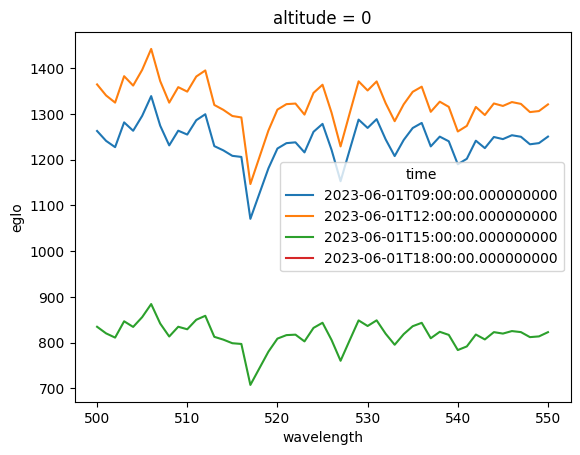

In [13]:
print("status per point:", result.status.values, "  (0 ok, 1 failed, 2 skipped)")
result.eglo.isel(altitude=0).plot.line(x='wavelength', hue='time');

The dark curve is the low-albedo morning point; the skipped point is
all-NaN. Had any point *failed*, its stderr would be collected in a
`failures_<timestamp>.log` in the working directory and its `.inp` file
kept for post-mortem.

## Instrument channels

Convolve the spectral result with spectral response functions — here two
boxcar channels — directly in `run(channels=...)` or as post-processing:

In [14]:
from pyradtran import convolve_channels

wl = np.linspace(400.0, 450.0, 51)
phi = np.zeros((2, wl.size))
phi[0, (wl >= 405) & (wl <= 420)] = 1.0
phi[1, (wl >= 430) & (wl <= 445)] = 1.0
srf = xr.DataArray(
    phi, dims=('channel', 'wavelength'),
    coords={'channel': ['ch1', 'ch2'], 'wavelength': wl},
)

channels = convolve_channels(result.drop_vars('status'), srf)
channels.eglo.isel(altitude=0).to_pandas().round(1)

channel,ch1,ch2
time,,
2023-06-01 09:00:00,NaN,NaN
2023-06-01 12:00:00,NaN,NaN
2023-06-01 15:00:00,NaN,NaN
2023-06-01 18:00:00,NaN,NaN


(For thermal work, `pyradtran.brightness_temperature()` inverts the
Planck function to convert channel radiances to brightness
temperatures.)

## Sensitivity kernels

`jacobian()` runs the batch twice — base and perturbed — and returns the
finite-difference kernel. Here: how much does surface irradiance react
to albedo?

d(eup)/d(albedo) at 425 nm: 1357.8 mW m-2 nm-1 per unit albedo


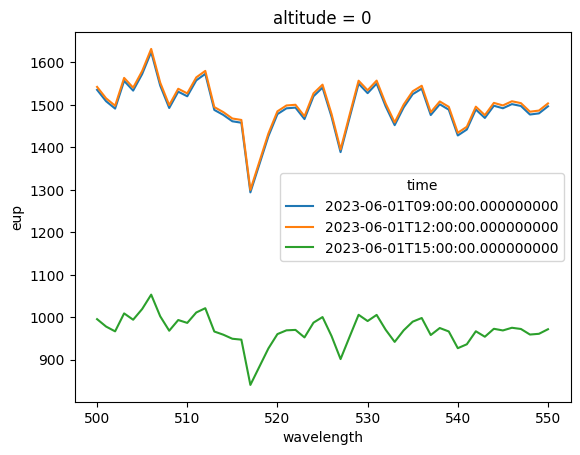

In [15]:
jac = ds.pyradtran.jacobian(
    'albedo', 0.05,
    config=cfg,
    show_progress=False,
)
jac.eup.isel(altitude=0).plot.line(x='wavelength', hue='time')
print(f"d(eup)/d(albedo) at 425 nm: "
      f"{float(jac.eup.sel(wavelength=425, method='nearest').mean()):.1f} "
      f"mW m-2 nm-1 per unit albedo")

## Where next

- {doc}`/guide/parameters` — the compact reference for everything shown here
- {doc}`/guide/outputs` — result datasets, NetCDF, channels, kernels
- {doc}`/guide/debugging` — when a run misbehaves
- {doc}`water_cloud` — putting `wc_file` and `wc_modify` to work